# Detailed 2D Graphics and Comprasion of Locomotion and Grooming

In [1]:
#preparation
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from seqikpy.utils import load_file, save_file, calculate_body_size, dict_to_nparray_pose

from seqikpy.alignment import AlignPose, convert_from_df3dpp_to_dict, convert_from_anipose_to_dict
from seqikpy.kinematic_chain import KinematicChainSeq
from seqikpy.leg_inverse_kinematics import LegInvKinSeq
from seqikpy.visualization import plot_3d_points, animate_3d_points
from seqikpy.body_config import neuromechfly_body_config
from seqikpy.head_inverse_kinematics import HeadInverseKinematics

# Set up the constant variables
leg_joint_angle_names = [
    "ThC_yaw",
    "ThC_pitch",
    "ThC_roll",
    "CTr_pitch",
    "CTr_roll",
    "FTi_pitch",
    "TiTa_pitch",
]
legs_to_align_locomotion = ["RF", "RM", "RH", "LF", "LM", "LH"]
legs_to_align_grooming = ["RF","LF"]

In [3]:
# Load the data, below contains the kinematics during locomotion
data_path_locomotion = Path("../data/df3d_pose_result__210902_PR_Fly1")
pose_data_locomotion = load_file(
    data_path_locomotion / "pose_result__210902_PR_Fly1_aligned.pkl"
)

# Convert the dictionary in a compatible format
converted_dict_full_locomotion = convert_from_df3dpp_to_dict(pose_data_locomotion)

# Select the time period where locomotion happens
converted_dict_locomotion = {}
for key, dict_v in converted_dict_full_locomotion.items():
    converted_dict_locomotion[key] = dict_v[300:500,:,:]

In [4]:
# Load the data, below contains the kinematics during grooming
data_path_grooming = Path("../data/anipose_220807_Fly002_002")
pose_data_grooming = load_file(data_path_grooming / "pose3d.h5")

# Convert the dictionary in a compatible format
converted_dict_full_grooming = convert_from_anipose_to_dict(
    pose_data_grooming, pts2align=neuromechfly_body_config.points_to_align
)

# Select the time period where grooming happens
converted_dict_grooming = {}
for key, dict_v in converted_dict_full_grooming.items():
    converted_dict_grooming[key] = dict_v[400:600, :, :]

In [5]:
_TEMPLATE_NMF_LOCOMOTION = {
    "RF_Coxa": np.array([0.35, -0.27, 0.400]),
    "RF_Femur": np.array([0.35, -0.27, -0.025]),
    "RF_Tibia": np.array([0.35, -0.27, -0.731]),
    "RF_Tarsus": np.array([0.35, -0.27, -1.249]),
    "RF_Claw": np.array([0.35, -0.27, -1.912]),
    "LF_Coxa": np.array([0.35, 0.27, 0.400]),
    "LF_Femur": np.array([0.35, 0.27, -0.025]),
    "LF_Tibia": np.array([0.35, 0.27, -0.731]),
    "LF_Tarsus": np.array([0.35, 0.27, -1.249]),
    "LF_Claw": np.array([0.35, 0.27, -1.912]),
    "RM_Coxa": np.array([0, -0.125, 0]),
    "RM_Femur": np.array([0, -0.125, -0.182]),
    "RM_Tibia": np.array([0, -0.125, -0.965]),
    "RM_Tarsus": np.array([0, -0.125, -1.633]),
    "RM_Claw": np.array([0, -0.125, -2.328]),
    "LM_Coxa": np.array([0, 0.125, 0]),
    "LM_Femur": np.array([0, 0.125, -0.182]),
    "LM_Tibia": np.array([0, 0.125, -0.965]),
    "LM_Tarsus": np.array([0, 0.125, -1.633]),
    "LM_Claw": np.array([0, 0.125, -2.328]),
    "RH_Coxa": np.array([-0.215, -0.087, -0.073]),
    "RH_Femur": np.array([-0.215, -0.087, -0.272]),
    "RH_Tibia": np.array([-0.215, -0.087, -1.108]),
    "RH_Tarsus": np.array([-0.215, -0.087, -1.793]),
    "RH_Claw": np.array([-0.215, -0.087, -2.588]),
    "LH_Coxa": np.array([-0.215, 0.087, -0.073]),
    "LH_Femur": np.array([-0.215, 0.087, -0.272]),
    "LH_Tibia": np.array([-0.215, 0.087, -1.108]),
    "LH_Tarsus": np.array([-0.215, 0.087, -1.793]),
    "LH_Claw": np.array([-0.215, 0.087, -2.588]),
}

body_config_locomotion = neuromechfly_body_config.deepcopy()
body_config_locomotion.template = _TEMPLATE_NMF_LOCOMOTION

In [6]:
_TEMPLATE_NMF_GROOMING = {
    "RF_Coxa": np.array([0.33, -0.17, 1.07]),
    "RF_Femur": np.array([0.33, -0.17, 0.67]),
    "RF_Tibia": np.array([0.33, -0.17, -0.02]),
    "RF_Tarsus": np.array([0.33, -0.17, -0.56]),
    "RF_Claw": np.array([0.33, -0.17, -1.19]),
    "LF_Coxa": np.array([0.33, 0.17, 1.07]),
    "LF_Femur": np.array([0.33, 0.17, 0.67]),
    "LF_Tibia": np.array([0.33, 0.17, -0.02]),
    "LF_Tarsus": np.array([0.33, 0.17, -0.56]),
    "LF_Claw": np.array([0.33, 0.17, -1.19]),
    "R_Antenna_base": np.array([1.01, -0.10, 1.41]),
    "L_Antenna_base": np.array([1.01, 0.10, 1.41]),
    "R_Antenna_edge": np.array([1.06, -0.10, 1.14]),
    "L_Antenna_edge": np.array([1.06, 0.10, 1.14]),
    "R_wing": np.array([0.08, -0.4, 1.43]),
    "L_wing": np.array([0.08, 0.4, 1.43]),
    "Neck": np.array([0.53, 0.0, 1.3]),
    "Thorax_mid": np.array([0.08, 0.0, 1.43]),
}

body_config_grooming = neuromechfly_body_config.deepcopy()
body_config_grooming.template = _TEMPLATE_NMF_GROOMING

In [7]:
# lets align the pose for locomotion
align_locomotion = AlignPose(
    pose_data_dict=converted_dict_locomotion,
    legs_list=legs_to_align_locomotion,
    include_claw=False,
    body_template=body_config_locomotion.template,
    # if body_size is none, then the size will be
    # calculated from the template
    body_size=None,
)

aligned_pos_locomotion = align_locomotion.align_pose(export_path=data_path_locomotion)

In [8]:
# lets align the pose for grooming
align_grooming = AlignPose(
    pose_data_dict=converted_dict_grooming,
    legs_list=legs_to_align_grooming,
    include_claw=False,
    body_template=body_config_grooming.template,
    # if body_size is none, then the size will be
    # calculated from the template
    body_size=None,
)

aligned_pos_grooming = align_grooming.align_pose(export_path=data_path_grooming)

(SEQUENTIAL INVERSE KINEMATICS)

In [9]:
# We are defining a set of initial seeds for the IK optimization of locomotion

_INITIAL_ANGLES_LOCOMOTION_RAD = {
    "RF": {
        # Base ThC yaw pitch CTr pitch
        "stage_1": np.array([0.0, 0.45, -0.07, -2.14]),
        # Base ThC yaw pitch roll CTr pitch CTr roll
        "stage_2": np.array([0.0, 0.45, -0.07, -0.32, -2.14, 1.4]),
        # Base ThC yaw pitch roll CTr pitch CTr roll FTi pitch
        "stage_3": np.array([0.0, 0.45, -0.07, -0.32, -2.14, -1.25, 1.48, 0.0]),
        # Base ThC yaw pitch roll CTr pitch CTr roll FTi pitch TiTa pitch
        "stage_4": np.array([0.0, 0.45, -0.07, -0.32, -2.14, -1.25, 1.48, 0.0, 0.0]),
    },
    "LF": {
        "stage_1": np.array([0.0, -0.45, -0.07, -2.14]),
        "stage_2": np.array([0.0, -0.45, -0.07, 0.32, -2.14, 1.4]),
        "stage_3": np.array([0.0, -0.45, -0.07, 0.32, -2.14, 1.25, 1.48, 0.0]),
        "stage_4": np.array([0.0, -0.45, -0.07, 0.32, -2.14, 1.25, 1.48, 0.0, 0.0]),
    },
    "RM": {
        "stage_1": np.array([0.0, 0.45, 0.37, -2.14]),
        "stage_2": np.array([0.0, 0.45, 0.37, -0.32, -2.14, 1.4]),
        "stage_3": np.array([0.0, 0.45, 0.37, -0.32, -2.14, -1.25, 1.48, 0.0]),
        "stage_4": np.array([0.0, 0.45, 0.37, -0.32, -2.14, -1.25, 1.48, 0.0, 0.0]),
    },
    "LM": {
        "stage_1": np.array([0.0, -0.45, 0.37, -2.14]),
        "stage_2": np.array([0.0, -0.45, 0.37, 0.32, -2.14, 1.4]),
        "stage_3": np.array([0.0, -0.45, 0.37, 0.32, -2.14, 1.25, 1.48, 0.0]),
        "stage_4": np.array([0.0, -0.45, 0.37, 0.32, -2.14, 1.25, 1.48, 0.0, 0.0]),
    },
    "RH": {
        "stage_1": np.array([0.0, 0.45, 0.07, -2.14]),
        "stage_2": np.array([0.0, 0.45, 0.07, -0.32, -2.14, 1.4]),
        "stage_3": np.array([0.0, 0.45, 0.07, -0.32, -2.14, -1.25, 1.48, 0.0]),
        "stage_4": np.array([0.0, 0.45, 0.07, -0.32, -2.14, -1.25, 1.48, 0.0, 0.0]),
    },
    "LH": {
        "stage_1": np.array([0.0, -0.45, 0.07, -2.14]),
        "stage_2": np.array([0.0, -0.45, 0.07, 0.32, -2.14, 1.4]),
        "stage_3": np.array([0.0, -0.45, 0.07, 0.32, -2.14, 1.25, 1.48, 0.0]),
        "stage_4": np.array([0.0, -0.45, 0.07, 0.32, -2.14, 1.25, 1.48, 0.0, 0.0]),
    },
}

body_config_locomotion.initial_angles_rad = _INITIAL_ANGLES_LOCOMOTION_RAD

In [10]:
#Head inverse kinematics for grooming (I changed compute_ant_angles as False due to an error to solve later)
class_hk = HeadInverseKinematics(
    aligned_pos=aligned_pos_grooming,
    body_template=body_config_grooming.template,
)
head_joint_angles = class_hk.compute_head_angles(
    export_path=data_path_grooming,
    compute_ant_angles=False # was originally True !!
)

In [11]:
# We are defining a set of initial seeds for the IK optimization of grooming
_INITIAL_ANGLES_GROOMING_RAD = {
    "RF": {
        # Base ThC yaw pitch CTr pitch
        "stage_1": np.array([0.0, 0.45, -0.07, -2.14]),
        # Base ThC yaw pitch roll CTr pitch CTr roll
        "stage_2": np.array([0.0, 0.45, -0.07, -0.32, -2.14, 1.4]),
        # Base ThC yaw pitch roll CTr pitch CTr roll FTi pitch
        "stage_3": np.array([0.0, 0.45, -0.07, -0.32, -2.14, -1.25, 1.48, 0.0]),
        # Base ThC yaw pitch roll CTr pitch CTr roll FTi pitch TiTa pitch
        "stage_4": np.array([0.0, 0.45, -0.07, -0.32, -2.14, -1.25, 1.48, 0.0, 0.0]),
    },
    # Same order for the contralateral leg
    "LF": {
        "stage_1": np.array([0.0, -0.45, -0.07, -2.14]),
        "stage_2": np.array([0.0, -0.45, -0.07, 0.32, -2.14, 1.4]),
        "stage_3": np.array([0.0, -0.45, -0.07, 0.32, -2.14, 1.25, 1.48, 0.0]),
        "stage_4": np.array([0.0, -0.45, -0.07, 0.32, -2.14, 1.25, 1.48, 0.0, 0.0]),
    },
}

body_config_grooming.initial_angles_rad = _INITIAL_ANGLES_GROOMING_RAD

In [12]:
# We determine the bounds for each joint DOF for locomotion
_BOUNDS_LOCOMOTION_DEG = {
    "RF_ThC_yaw": (-180, 180),
    "RF_ThC_pitch": (-90, 90),
    "RF_ThC_roll": (-180, 180),
    "RF_CTr_pitch": (-180, 180),
    "RF_FTi_pitch": (-180, 180),
    "RF_CTr_roll": (-180, 180),
    "RF_TiTa_pitch": (-180, 0),
    "RM_ThC_yaw": (-50, 50),
    "RM_ThC_pitch": (-180, 180),
    "RM_ThC_roll": (-180, 0),
    "RM_CTr_pitch": (-180, 180),
    "RM_FTi_pitch": (-180, 180),
    "RM_CTr_roll": (-180, 180),
    "RM_TiTa_pitch": (-180, 0),
    "RH_ThC_yaw": (-50, 50),
    "RH_ThC_pitch": (-50, 50),
    "RH_ThC_roll": (-180, 0),
    "RH_CTr_pitch": (-180, 0),
    "RH_FTi_pitch": (-180, 180),
    "RH_CTr_roll": (-180, 180),
    "RH_TiTa_pitch": (-180, 0),
    "LF_ThC_yaw": (-180, 180),
    "LF_ThC_pitch": (-90, 90),
    "LF_ThC_roll": (-180, 180),
    "LF_CTr_pitch": (-180, 180),
    "LF_FTi_pitch": (-180, 180),
    "LF_CTr_roll": (-180, 180),
    "LF_TiTa_pitch": (-180, 0),
    "LM_ThC_yaw": (-50, 50),
    "LM_ThC_pitch": (-180, 180),
    "LM_ThC_roll": (0, 180),
    "LM_CTr_pitch": (-180, 180),
    "LM_FTi_pitch": (-180, 180),
    "LM_CTr_roll": (-180, 180),
    "LM_TiTa_pitch": (-180, 0),
    "LH_ThC_yaw": (-50, 50),
    "LH_ThC_pitch": (-50, 50),
    "LH_ThC_roll": (0, 180),
    "LH_CTr_pitch": (-180, 0),
    "LH_FTi_pitch": (-180, 180),
    "LH_CTr_roll": (-180, 180),
    "LH_TiTa_pitch": (-180, 0),
}

body_config_locomotion.set_dof_bounds_in_deg(_BOUNDS_LOCOMOTION_DEG)

In [13]:
# We determine the bounds for each joint DOF for grooming
_BOUNDS_GROOMING_DEG = {
    "RF_ThC_roll": (-130, 50),
    "RF_ThC_yaw": (-50, 50),
    "RF_ThC_pitch": (-40, 60),
    "RF_CTr_pitch": (-180, 0),
    "RF_CTr_roll": (-150, 0),
    "RF_FTi_pitch": (0, 170),
    "RF_TiTa_pitch": (-150, 0),
    "LF_ThC_roll": (-50, 130),
    "LF_ThC_yaw": (-50, 50),
    "LF_ThC_pitch": (-40, 60),
    "LF_CTr_pitch": (-180, 0),
    "LF_CTr_roll": (0, 150),
    "LF_FTi_pitch": (0, 170),
    "LF_TiTa_pitch": (-150, 0),
}

body_config_grooming.set_dof_bounds_in_deg(_BOUNDS_GROOMING_DEG)

In [14]:
# Initialize the necessary classes for locomotion
kin_chain_locomotion = KinematicChainSeq(
    bounds_dof=body_config_locomotion.dof_bounds_rad,
    body_size=calculate_body_size(body_config_locomotion.template, legs_to_align_locomotion),
    # perform ik on all 6 legs
    legs_list=legs_to_align_locomotion,
)

class_seq_ik_locomotion = LegInvKinSeq(
    aligned_pos=aligned_pos_locomotion,
    kinematic_chain_class=kin_chain_locomotion,
    initial_angles=body_config_locomotion.initial_angles_rad,
)

In [15]:
# Initialize the necessary classes for grooming
kin_chain_grooming = KinematicChainSeq(
    bounds_dof=body_config_grooming.dof_bounds_rad,
    body_size=calculate_body_size(
        body_config_grooming.template,
        legs_list=legs_to_align_grooming
    ),
    legs_list=legs_to_align_grooming,
)

class_seq_ik_grooming = LegInvKinSeq(
    aligned_pos=aligned_pos_grooming,
    kinematic_chain_class=kin_chain_grooming,
    initial_angles=body_config_grooming.initial_angles_rad,
)

In [16]:
#IK process for locomotion
leg_joint_angles_locomotion, forward_kinematics_locomotion = class_seq_ik_locomotion.run_ik_and_fk(
    export_path=data_path_locomotion,
    hide_progress_bar=False
)

LH stage 4: 100%|██████████| 200/200 [00:12<00:00, 16.11it/s]


In [19]:
#IK process for grooming
leg_joint_angles_grooming, forward_kinematics_grooming = class_seq_ik_grooming.run_ik_and_fk(
    export_path=data_path_grooming,
    hide_progress_bar=False
)

LF stage 4: 100%|██████████| 200/200 [00:11<00:00, 17.65it/s]


In [22]:
#Saving joint angles and forward kinematics to use later
export_folder=Path("..\data\inverse-kinematics-processed-data-for-comprasion")
save_file(export_folder/"locomotion_leg_joint_angles_processed.pkl",leg_joint_angles_locomotion)
save_file(export_folder/"locomotion_forward_kinematics_processed.pkl",forward_kinematics_locomotion)

In [23]:
save_file(export_folder/"grooming_leg_joint_angles_processed.pkl",leg_joint_angles_grooming)
save_file(export_folder/"grooming_forward_kinematics_processed.pkl",forward_kinematics_grooming)

# Visualization and Graphics

In [78]:
#loading processed data
import_folder=Path("..\data\inverse-kinematics-processed-data-for-comprasion")
    
locomotion_leg_joint_angles=load_file(import_folder/"locomotion_leg_joint_angles_processed.pkl")
locomotion_forward_kinematics=load_file(import_folder/"locomotion_forward_kinematics_processed.pkl")

grooming_leg_joint_angles=load_file(import_folder/"grooming_leg_joint_angles_processed.pkl")
grooming_forward_kinematics=load_file(import_folder/"grooming_forward_kinematics_processed.pkl")

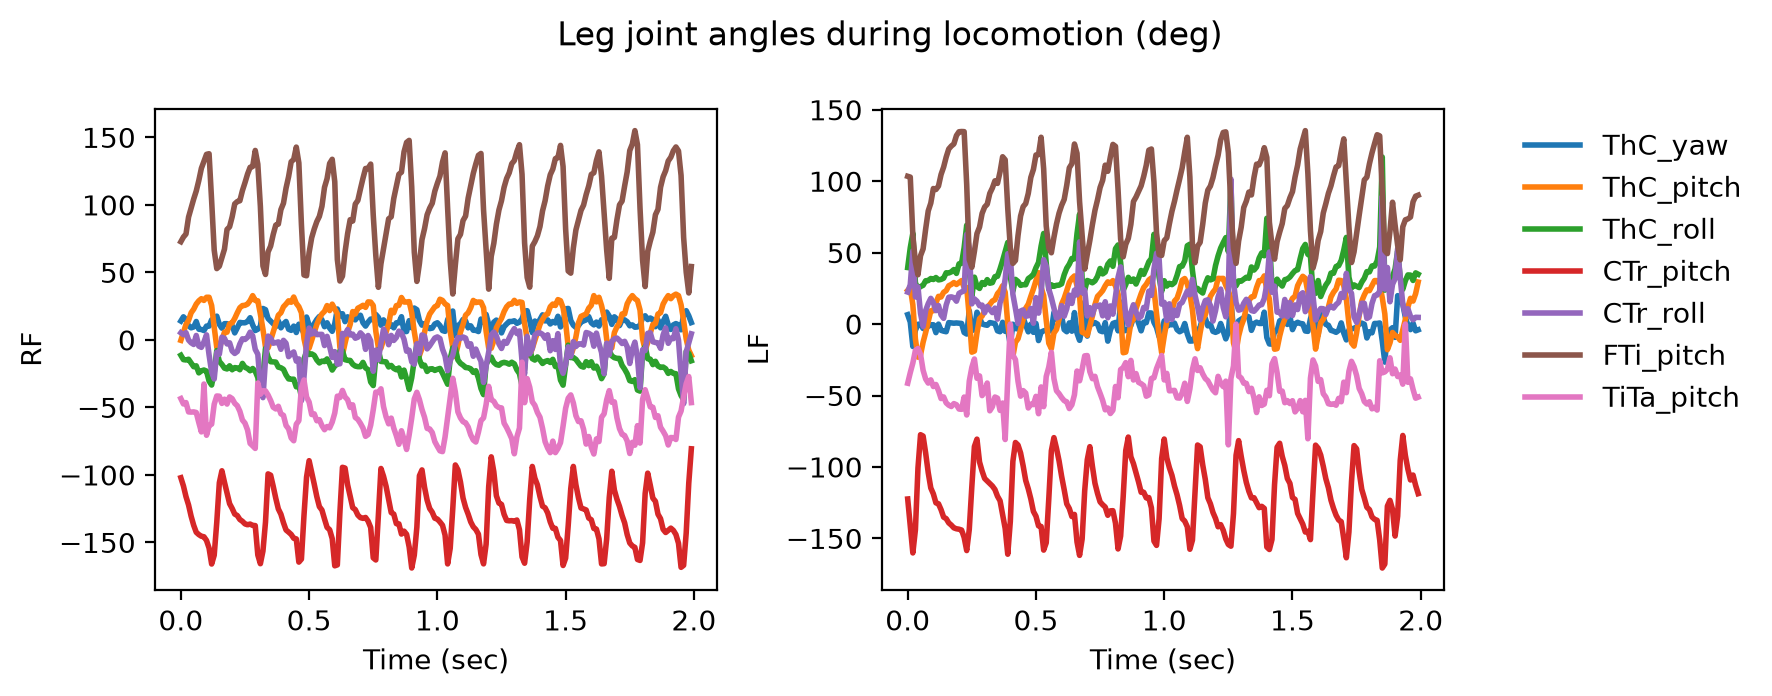

In [79]:
#visualization of RF and LF legs for locomotion only
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), dpi=200)
axs=axs.flatten()

for angle_name in leg_joint_angle_names:
    for i, leg_name in enumerate(["RF", "LF"]):
        axs[i].plot(
            np.rad2deg(locomotion_leg_joint_angles[f"Angle_{leg_name}_{angle_name}"]),
            label=angle_name,
            lw=2,
        )
        axs[i].set_ylabel(leg_name)

time_step = 1e-2
for ax in axs:
    ax.set_xticklabels(np.array(ax.get_xticks() * time_step, dtype='f'))

axs[0].set_xlabel("Time (sec)")
axs[1].set_xlabel("Time (sec)")

axs[1].legend(bbox_to_anchor=(1.1, 1), frameon=False)
plt.suptitle("Leg joint angles during locomotion (deg)")
plt.tight_layout()
# fig.savefig("../results_comprasion/RF_and_LF_joints_follow_ikpy_locomotion.png", bbox_inches="tight")
plt.show()

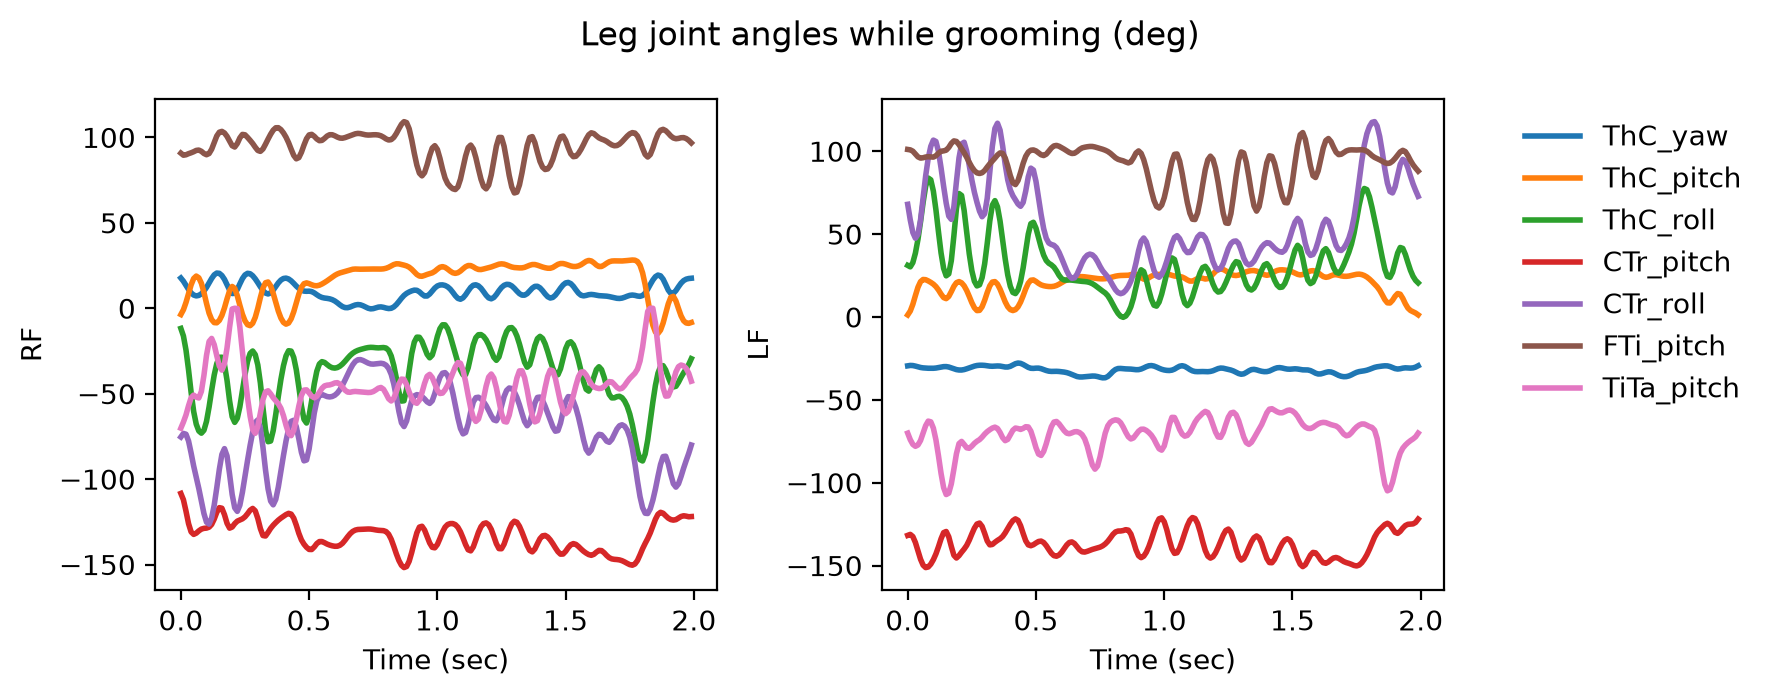

In [80]:
# visualization of the same legs for grooming
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5), dpi=200)

axs = axs.flatten()
for angle_name in leg_joint_angle_names:
    for i, leg_name in enumerate(["RF", "LF"]):
        axs[i].plot(
            np.rad2deg(grooming_leg_joint_angles[f"Angle_{leg_name}_{angle_name}"]),
            label=angle_name,
            lw=2,
        )
        axs[i].set_ylabel(leg_name)

time_step = 1e-2
for ax in axs:
    ax.set_xticklabels(np.array(ax.get_xticks() * time_step, dtype='f'))


axs[0].set_xlabel("Time (sec)")
axs[1].set_xlabel("Time (sec)")

axs[1].legend(bbox_to_anchor=(1.1, 1), frameon=False)

plt.suptitle("Leg joint angles while grooming (deg)")
plt.tight_layout()

# fig.savefig("../results/RF_and_LF_joints_follow_ikpy_grooming.png", bbox_inches="tight")
plt.show()

If we were to compare these two datas, it would be evident that while locomotion demonstrates a repetitive pattern with FTi pitch and CTr pitch angles changing the most, grooming shows a more complicated and momentary motion. In grooming, it's remarkable that some joint angles demonstrate opposite patterns in Right and Left front legs, particularly in TiTa Pitch, CTr roll and ThC roll.

In [81]:
locomotion_leg_joint_angles.keys()

dict_keys(['Angle_RF_ThC_yaw', 'Angle_RF_ThC_pitch', 'Angle_RF_ThC_roll', 'Angle_RF_CTr_pitch', 'Angle_RF_CTr_roll', 'Angle_RF_FTi_pitch', 'Angle_RF_TiTa_pitch', 'Angle_RM_ThC_yaw', 'Angle_RM_ThC_pitch', 'Angle_RM_ThC_roll', 'Angle_RM_CTr_pitch', 'Angle_RM_CTr_roll', 'Angle_RM_FTi_pitch', 'Angle_RM_TiTa_pitch', 'Angle_RH_ThC_yaw', 'Angle_RH_ThC_pitch', 'Angle_RH_ThC_roll', 'Angle_RH_CTr_pitch', 'Angle_RH_CTr_roll', 'Angle_RH_FTi_pitch', 'Angle_RH_TiTa_pitch', 'Angle_LF_ThC_yaw', 'Angle_LF_ThC_pitch', 'Angle_LF_ThC_roll', 'Angle_LF_CTr_pitch', 'Angle_LF_CTr_roll', 'Angle_LF_FTi_pitch', 'Angle_LF_TiTa_pitch', 'Angle_LM_ThC_yaw', 'Angle_LM_ThC_pitch', 'Angle_LM_ThC_roll', 'Angle_LM_CTr_pitch', 'Angle_LM_CTr_roll', 'Angle_LM_FTi_pitch', 'Angle_LM_TiTa_pitch', 'Angle_LH_ThC_yaw', 'Angle_LH_ThC_pitch', 'Angle_LH_ThC_roll', 'Angle_LH_CTr_pitch', 'Angle_LH_CTr_roll', 'Angle_LH_FTi_pitch', 'Angle_LH_TiTa_pitch'])

In [82]:
leg_joint_angle_names

['ThC_yaw',
 'ThC_pitch',
 'ThC_roll',
 'CTr_pitch',
 'CTr_roll',
 'FTi_pitch',
 'TiTa_pitch']

In [83]:
import pandas as pd

In [84]:
np.arange(7)

array([0, 1, 2, 3, 4, 5, 6])

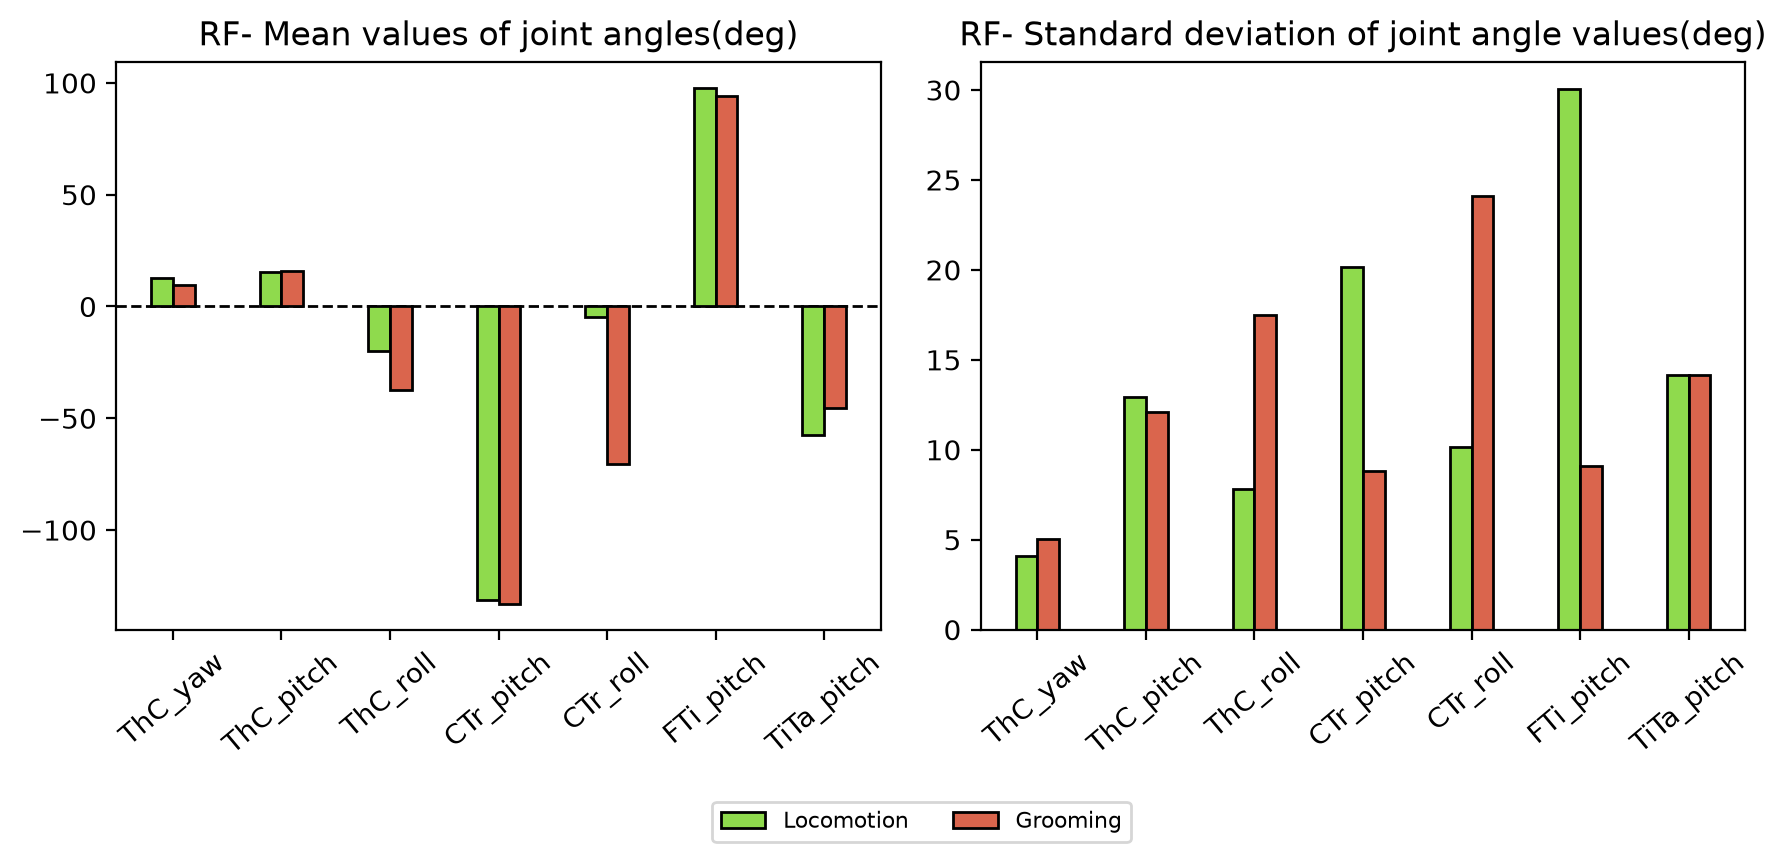

In [85]:
#visualization of mean, min, max, range and standard deviaton of angles during both motions
fig,axs= plt.subplots(1, 2, figsize=(9, 4), dpi=200)
axs=axs.flatten()

mean_values_locomotion=[]
std_values_locomotion=[]

mean_values_grooming=[]
std_values_grooming=[]

for angle in leg_joint_angle_names:
    mean_values_locomotion.append(np.mean(np.rad2deg(locomotion_leg_joint_angles[f"Angle_RF_{angle}"])))
    std_values_locomotion.append(np.std(np.rad2deg(locomotion_leg_joint_angles[f"Angle_RF_{angle}"])))

    mean_values_grooming.append(np.mean(np.rad2deg(grooming_leg_joint_angles[f"Angle_RF_{angle}"])))
    std_values_grooming.append(np.std(np.rad2deg(grooming_leg_joint_angles[f"Angle_RF_{angle}"])))

axs[0].bar(np.arange(7)-0.1,mean_values_locomotion,color="#8fda4d",edgecolor="black",width=0.2)
axs[0].bar(np.arange(7)+0.1,mean_values_grooming,color="#da654d",edgecolor="black",width=0.2)
fig.legend(["Locomotion", "Grooming"], bbox_to_anchor=(0.64,-0.001), ncol=2, fontsize=8)

axs[0].axhline(0, color='black', linestyle='--', linewidth=1, zorder=0)
axs[0].set_xticks(np.arange(7))
axs[0].set_xticklabels(leg_joint_angle_names, rotation=40,fontsize=10)
axs[0].set_title("RF- Mean values of joint angles(deg)")

axs[1].bar(np.arange(7)-0.1,std_values_locomotion,color="#8fda4d",edgecolor="black",width=0.2)
axs[1].bar(np.arange(7)+0.1,std_values_grooming,color="#da654d",edgecolor="black",width=0.2)

axs[1].set_xticks(np.arange(7))
axs[1].set_xticklabels(leg_joint_angle_names, rotation=40,fontsize=10)
axs[1].set_title("RF- Standard deviation of joint angle values(deg)")



plt.tight_layout()
plt.show()




According to the graphics, we can see that the mean values  CTr roll joint angles differ most when locomotion and grooming are compared, which can be significant for PCA . For standard deviations, we can see that ThC roll and CTr roll show the biggest change while grooming, whereas CTr pitch and FTi pitch angles have the highest standart deviation in locomotion. These changes can also be significant for machine learning process.

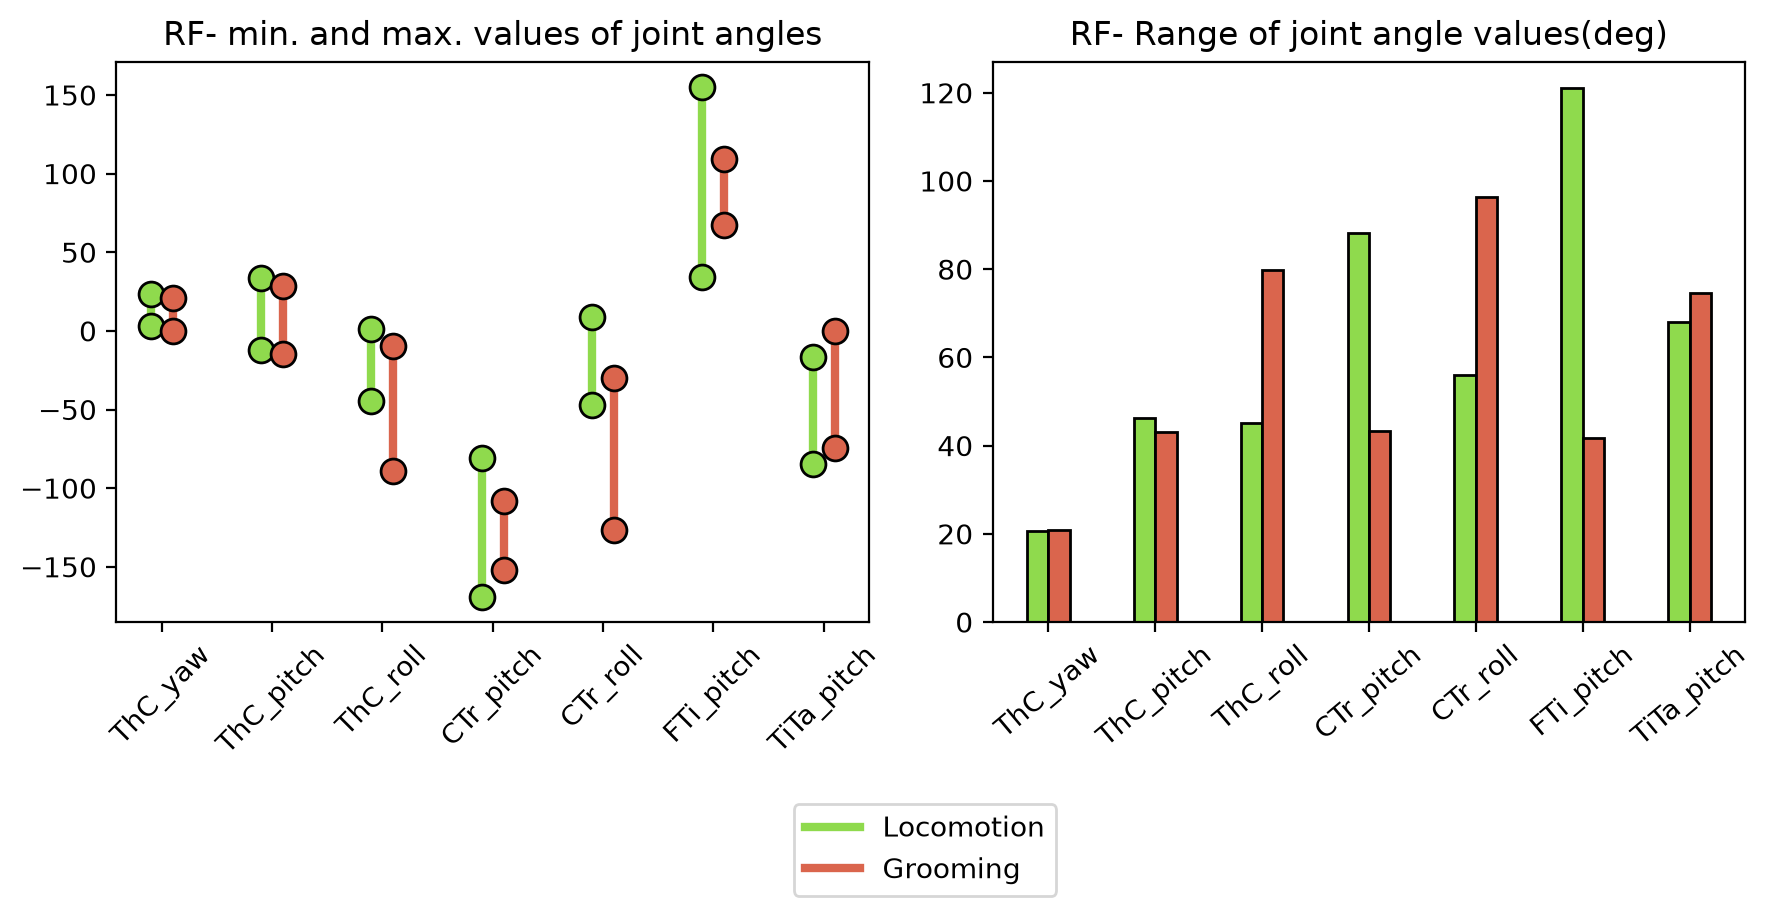

In [86]:
# Now I will make the graphics showing the range of motion by degre for each joint angle, both for locomotion and grooming
from matplotlib.lines import Line2D
fig,axs= plt.subplots(1, 2, figsize=(9, 4), dpi=200)
axs=axs.flatten()

max_values_locomotion=[]
min_values_locomotion=[]

max_values_grooming=[]
min_values_grooming=[]

for angle in leg_joint_angle_names:
    max_values_locomotion.append(np.max(np.rad2deg(locomotion_leg_joint_angles[f"Angle_RF_{angle}"])))
    min_values_locomotion.append(np.min(np.rad2deg(locomotion_leg_joint_angles[f"Angle_RF_{angle}"])))

    max_values_grooming.append(np.max(np.rad2deg(grooming_leg_joint_angles[f"Angle_RF_{angle}"])))
    min_values_grooming.append(np.min(np.rad2deg(grooming_leg_joint_angles[f"Angle_RF_{angle}"])))

axs[0].scatter(np.arange(7)-0.1, min_values_locomotion, color="#8fda4d", edgecolors='black', s=80, zorder=3)
axs[0].scatter(np.arange(7)-0.1, max_values_locomotion, color="#8fda4d", edgecolors='black', s=80, zorder=3)

axs[0].scatter(np.arange(7)+0.1, min_values_grooming, color="#da654d", edgecolors='black', s=80, zorder=3)
axs[0].scatter(np.arange(7)+0.1, max_values_grooming, color="#da654d", edgecolors='black', s=80, zorder=3)


axs[0].vlines(np.arange(7)+0.1, ymin=min_values_grooming, ymax=max_values_grooming, colors="#da654d", linewidth=3)
axs[0].vlines(np.arange(7)-0.1, ymin=min_values_locomotion, ymax=max_values_locomotion, colors="#8fda4d", linewidth=3)

axs[0].set_xticks(np.arange(7),leg_joint_angle_names,rotation=45)
axs[0].set_title("RF- min. and max. values of joint angles")


axs[1].bar(np.arange(7)-0.1,np.array(max_values_locomotion)-np.array(min_values_locomotion),color="#8fda4d",edgecolor="black",width=0.2)
axs[1].bar(np.arange(7)+0.1,np.array(max_values_grooming)-np.array(min_values_grooming),color="#da654d",edgecolor="black",width=0.2)

axs[1].set_xticks(np.arange(7))
axs[1].set_xticklabels(leg_joint_angle_names, rotation=40,fontsize=10)
axs[1].set_title("RF- Range of joint angle values(deg)")

fig.legend(handles=[
    Line2D([0], [0], color="#8fda4d", markerfacecolor="#8fda4d", 
           markeredgecolor='black', markersize=6, linewidth=3, label='Locomotion'),
    Line2D([0], [0], color="#da654d", markerfacecolor="#da654d", 
           markeredgecolor='black', markersize=6, linewidth=3, label='Grooming')
],bbox_to_anchor=(0.6,-0.001))

plt.tight_layout()
plt.show()

As we can see from the graphics, locomotion and grooming shows a significant difference in angle values of CTr roll. FTi pitch angles show the most difference by range in these motions. Additionally, ThC roll, CTr pitch and CTr roll have remarkable differences between the ranges of grooming and locomotion.

finally, we can try generating heatmaps for each motion to see if there is a correlation among any joint angle values. This map might help us reducing the components in machine learning process.

In [88]:
import seaborn as sns
import pandas as pd

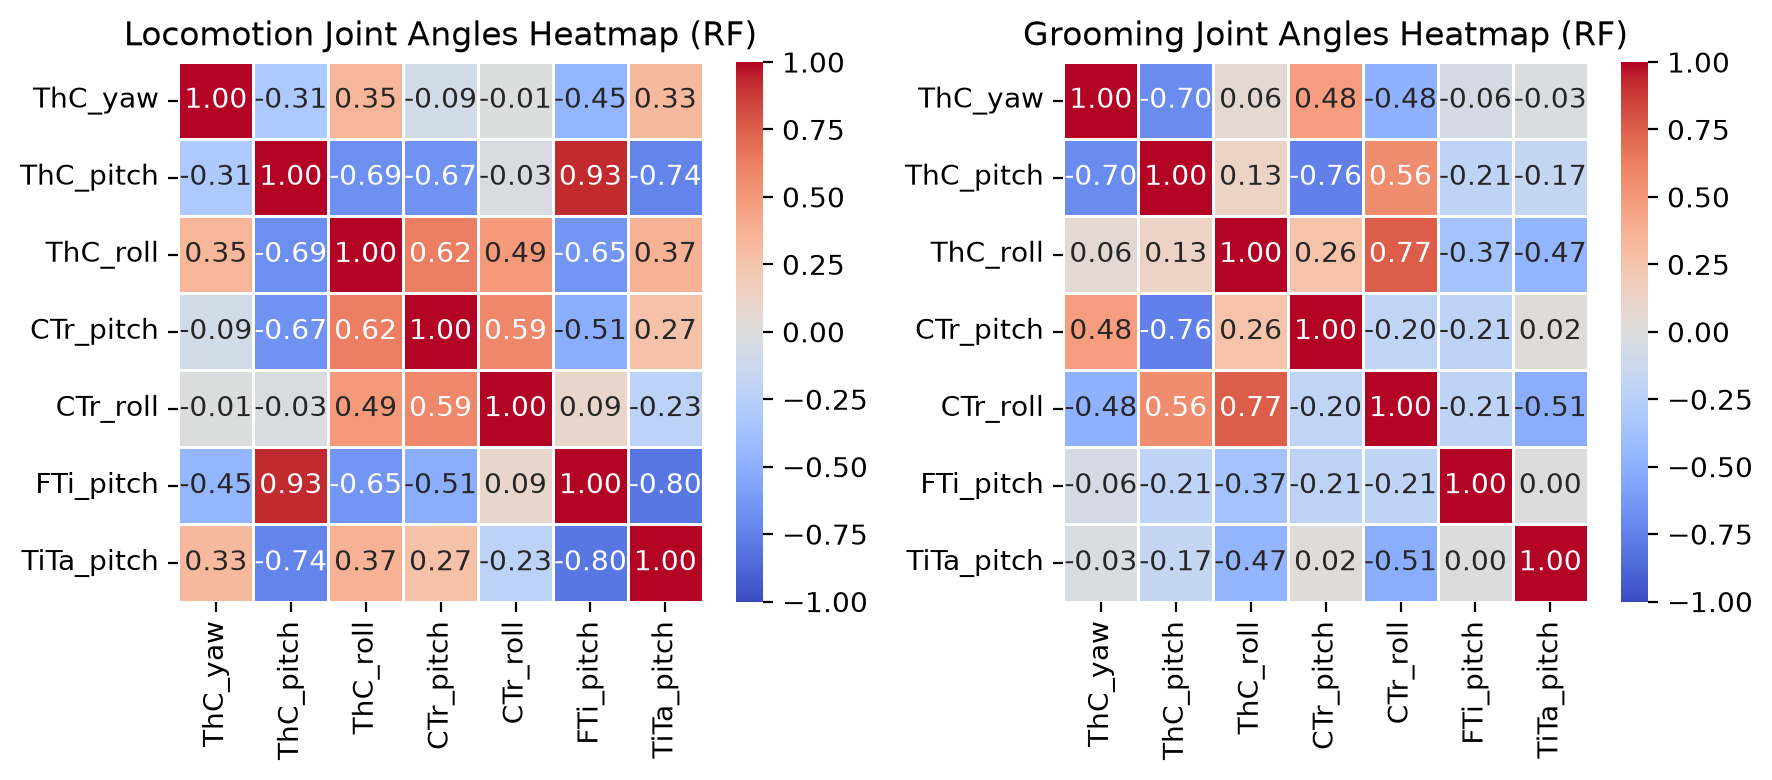

In [89]:
fig,axs= plt.subplots(1, 2, figsize=(9, 4), dpi=200)
axs=axs.flatten()

RF_locomotion_angles={}
RF_grooming_angles={}

for angle in leg_joint_angle_names:
    RF_locomotion_angles[angle]=(np.rad2deg(locomotion_leg_joint_angles[f"Angle_RF_{angle}"]))
    RF_grooming_angles[angle]=(np.rad2deg(grooming_leg_joint_angles[f"Angle_RF_{angle}"]))


df_locomotion=pd.DataFrame(RF_locomotion_angles)
locomotion_corr_matrix=df_locomotion.corr()
sns.heatmap(
    data=locomotion_corr_matrix,   
    ax=axs[0],                     
    annot=True,                
    fmt='.2f',                 
    cmap='coolwarm',           
    vmin=-1, vmax=1,           
    linewidths=0.5,            
    linecolor='white'          
)

df_grooming=pd.DataFrame(RF_grooming_angles)
grooming_corr_matrix=df_grooming.corr()
sns.heatmap(
    data=grooming_corr_matrix,   
    ax=axs[1],                     
    annot=True,                
    fmt='.2f',                 
    cmap='coolwarm',           
    vmin=-1, vmax=1,           
    linewidths=0.5,            
    linecolor='white'          
)


axs[0].set_title('Locomotion Joint Angles Heatmap (RF)')
axs[1].set_title('Grooming Joint Angles Heatmap (RF)')

plt.tight_layout()
plt.show()

We can see here that in locomotion, there is a strong positive correlation between ThC pitch and FTi pitch. In addition, There is a negative correlation between TiTa pitch-FTi pitch and ThC pitch- TiTa pitch joints which is strong enough, although not as those between the former two.

For grooming, we can say that there is a positive correlation between ThC roll and CTr roll, and negative correlation between ThC pitch-CTr pitch and ThC pitch-ThC yaw joint angles.

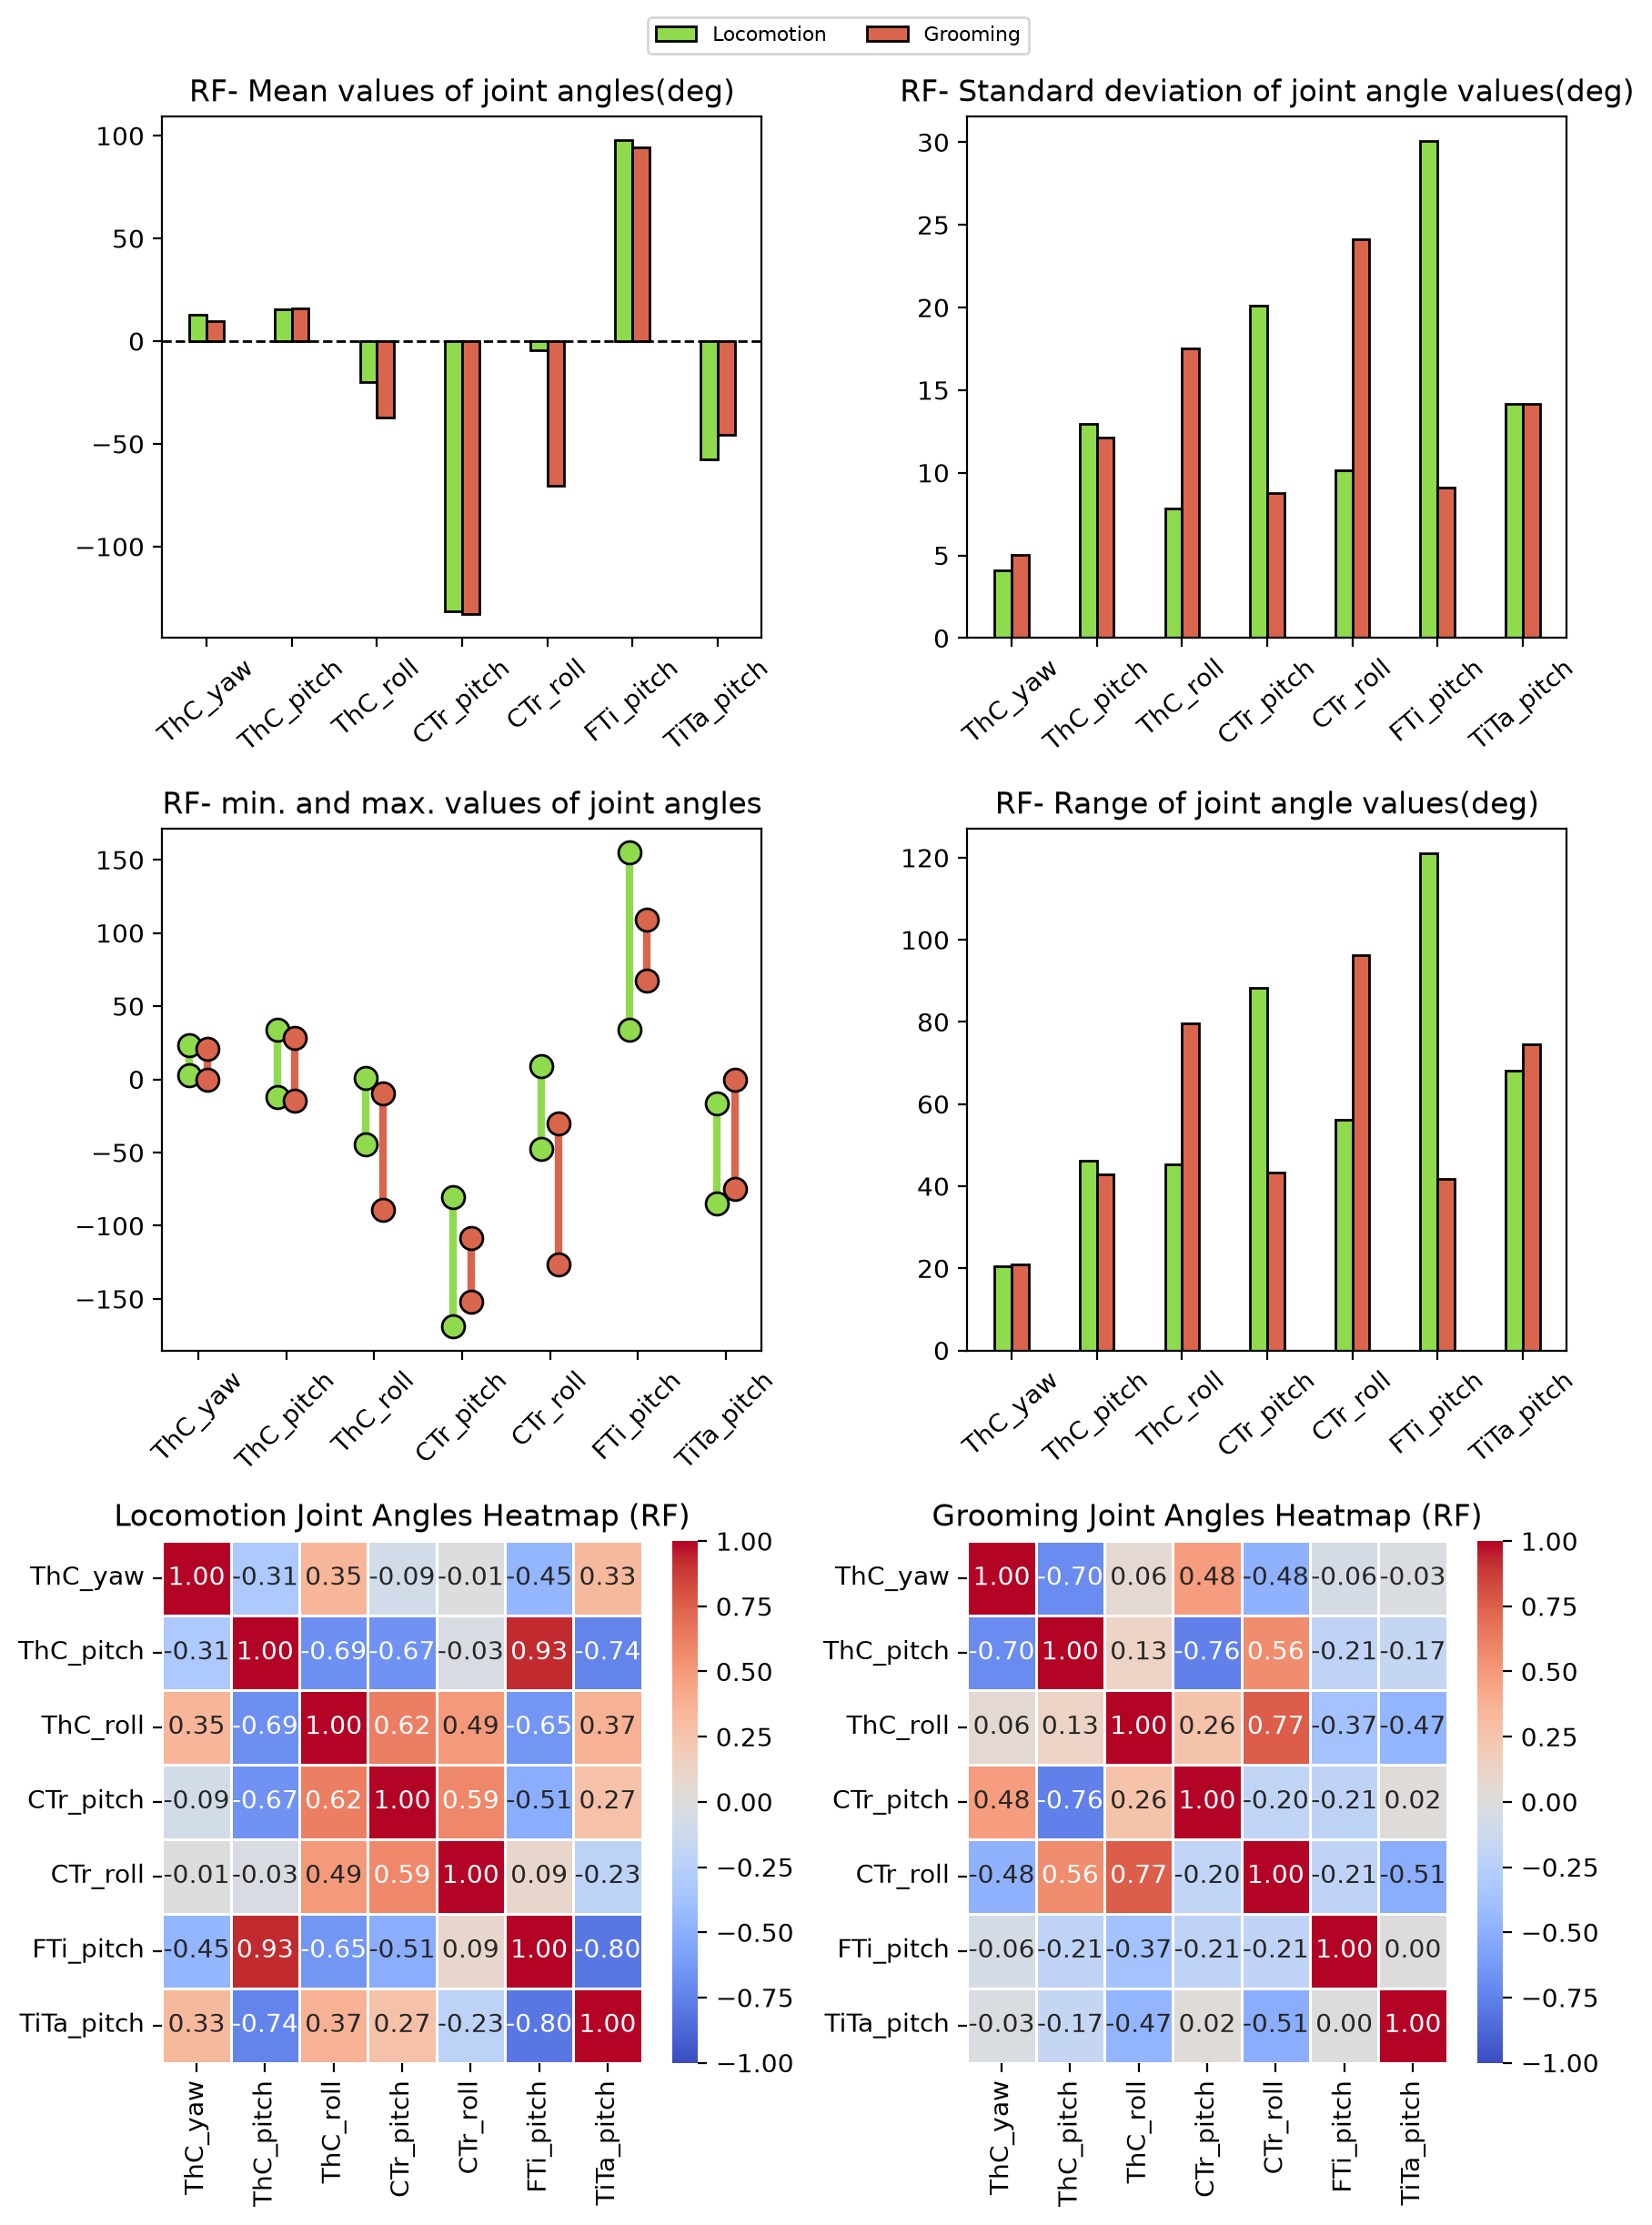

In [ ]:
# Now we can compile the graphics.
fig,axs= plt.subplots(3, 2, figsize=(9, 12), dpi=200)
axs=axs.flatten()

mean_values_locomotion=[]
std_values_locomotion=[]

mean_values_grooming=[]
std_values_grooming=[]

for angle in leg_joint_angle_names:
    mean_values_locomotion.append(np.mean(np.rad2deg(locomotion_leg_joint_angles[f"Angle_RF_{angle}"])))
    std_values_locomotion.append(np.std(np.rad2deg(locomotion_leg_joint_angles[f"Angle_RF_{angle}"])))

    mean_values_grooming.append(np.mean(np.rad2deg(grooming_leg_joint_angles[f"Angle_RF_{angle}"])))
    std_values_grooming.append(np.std(np.rad2deg(grooming_leg_joint_angles[f"Angle_RF_{angle}"])))

axs[0].bar(np.arange(7)-0.1,mean_values_locomotion,color="#8fda4d",edgecolor="black",width=0.2)
axs[0].bar(np.arange(7)+0.1,mean_values_grooming,color="#da654d",edgecolor="black",width=0.2)
fig.legend(["Locomotion", "Grooming"], bbox_to_anchor=(0.64,1.02), ncol=2, fontsize=8)

axs[0].axhline(0, color='black', linestyle='--', linewidth=1, zorder=0)
axs[0].set_xticks(np.arange(7))
axs[0].set_xticklabels(leg_joint_angle_names, rotation=40,fontsize=10)
axs[0].set_title("RF- Mean values of joint angles(deg)")

axs[1].bar(np.arange(7)-0.1,std_values_locomotion,color="#8fda4d",edgecolor="black",width=0.2)
axs[1].bar(np.arange(7)+0.1,std_values_grooming,color="#da654d",edgecolor="black",width=0.2)

axs[1].set_xticks(np.arange(7))
axs[1].set_xticklabels(leg_joint_angle_names, rotation=40,fontsize=10)
axs[1].set_title("RF- Standard deviation of joint angle values(deg)")


max_values_locomotion=[]
min_values_locomotion=[]

max_values_grooming=[]
min_values_grooming=[]

for angle in leg_joint_angle_names:
    max_values_locomotion.append(np.max(np.rad2deg(locomotion_leg_joint_angles[f"Angle_RF_{angle}"])))
    min_values_locomotion.append(np.min(np.rad2deg(locomotion_leg_joint_angles[f"Angle_RF_{angle}"])))

    max_values_grooming.append(np.max(np.rad2deg(grooming_leg_joint_angles[f"Angle_RF_{angle}"])))
    min_values_grooming.append(np.min(np.rad2deg(grooming_leg_joint_angles[f"Angle_RF_{angle}"])))

axs[2].scatter(np.arange(7)-0.1, min_values_locomotion, color="#8fda4d", edgecolors='black', s=80, zorder=3)
axs[2].scatter(np.arange(7)-0.1, max_values_locomotion, color="#8fda4d", edgecolors='black', s=80, zorder=3)

axs[2].scatter(np.arange(7)+0.1, min_values_grooming, color="#da654d", edgecolors='black', s=80, zorder=3)
axs[2].scatter(np.arange(7)+0.1, max_values_grooming, color="#da654d", edgecolors='black', s=80, zorder=3)


axs[2].vlines(np.arange(7)+0.1, ymin=min_values_grooming, ymax=max_values_grooming, colors="#da654d", linewidth=3)
axs[2].vlines(np.arange(7)-0.1, ymin=min_values_locomotion, ymax=max_values_locomotion, colors="#8fda4d", linewidth=3)

axs[2].set_xticks(np.arange(7),leg_joint_angle_names,rotation=45)
axs[2].set_title("RF- min. and max. values of joint angles")


axs[3].bar(np.arange(7)-0.1,np.array(max_values_locomotion)-np.array(min_values_locomotion),color="#8fda4d",edgecolor="black",width=0.2)
axs[3].bar(np.arange(7)+0.1,np.array(max_values_grooming)-np.array(min_values_grooming),color="#da654d",edgecolor="black",width=0.2)

axs[3].set_xticks(np.arange(7))
axs[3].set_xticklabels(leg_joint_angle_names, rotation=40,fontsize=10)
axs[3].set_title("RF- Range of joint angle values(deg)")

RF_locomotion_angles={}
RF_grooming_angles={}

for angle in leg_joint_angle_names:
    RF_locomotion_angles[angle]=(np.rad2deg(locomotion_leg_joint_angles[f"Angle_RF_{angle}"]))
    RF_grooming_angles[angle]=(np.rad2deg(grooming_leg_joint_angles[f"Angle_RF_{angle}"]))


df_locomotion=pd.DataFrame(RF_locomotion_angles)
locomotion_corr_matrix=df_locomotion.corr()
sns.heatmap(
    data=locomotion_corr_matrix,   
    ax=axs[4],                     
    annot=True,                
    fmt='.2f',                 
    cmap='coolwarm',           
    vmin=-1, vmax=1,           
    linewidths=0.5,            
    linecolor='white'          
)

df_grooming=pd.DataFrame(RF_grooming_angles)
grooming_corr_matrix=df_grooming.corr()
sns.heatmap(
    data=grooming_corr_matrix,   
    ax=axs[5],                     
    annot=True,                
    fmt='.2f',                 
    cmap='coolwarm',           
    vmin=-1, vmax=1,           
    linewidths=0.5,            
    linecolor='white'          
)


axs[4].set_title('Locomotion Joint Angles Heatmap (RF)')
axs[5].set_title('Grooming Joint Angles Heatmap (RF)')


plt.tight_layout()
plt.show()



### Histograms
Now we will make histogram to see the distrubution of leg joint angle values more clearly in both motions.

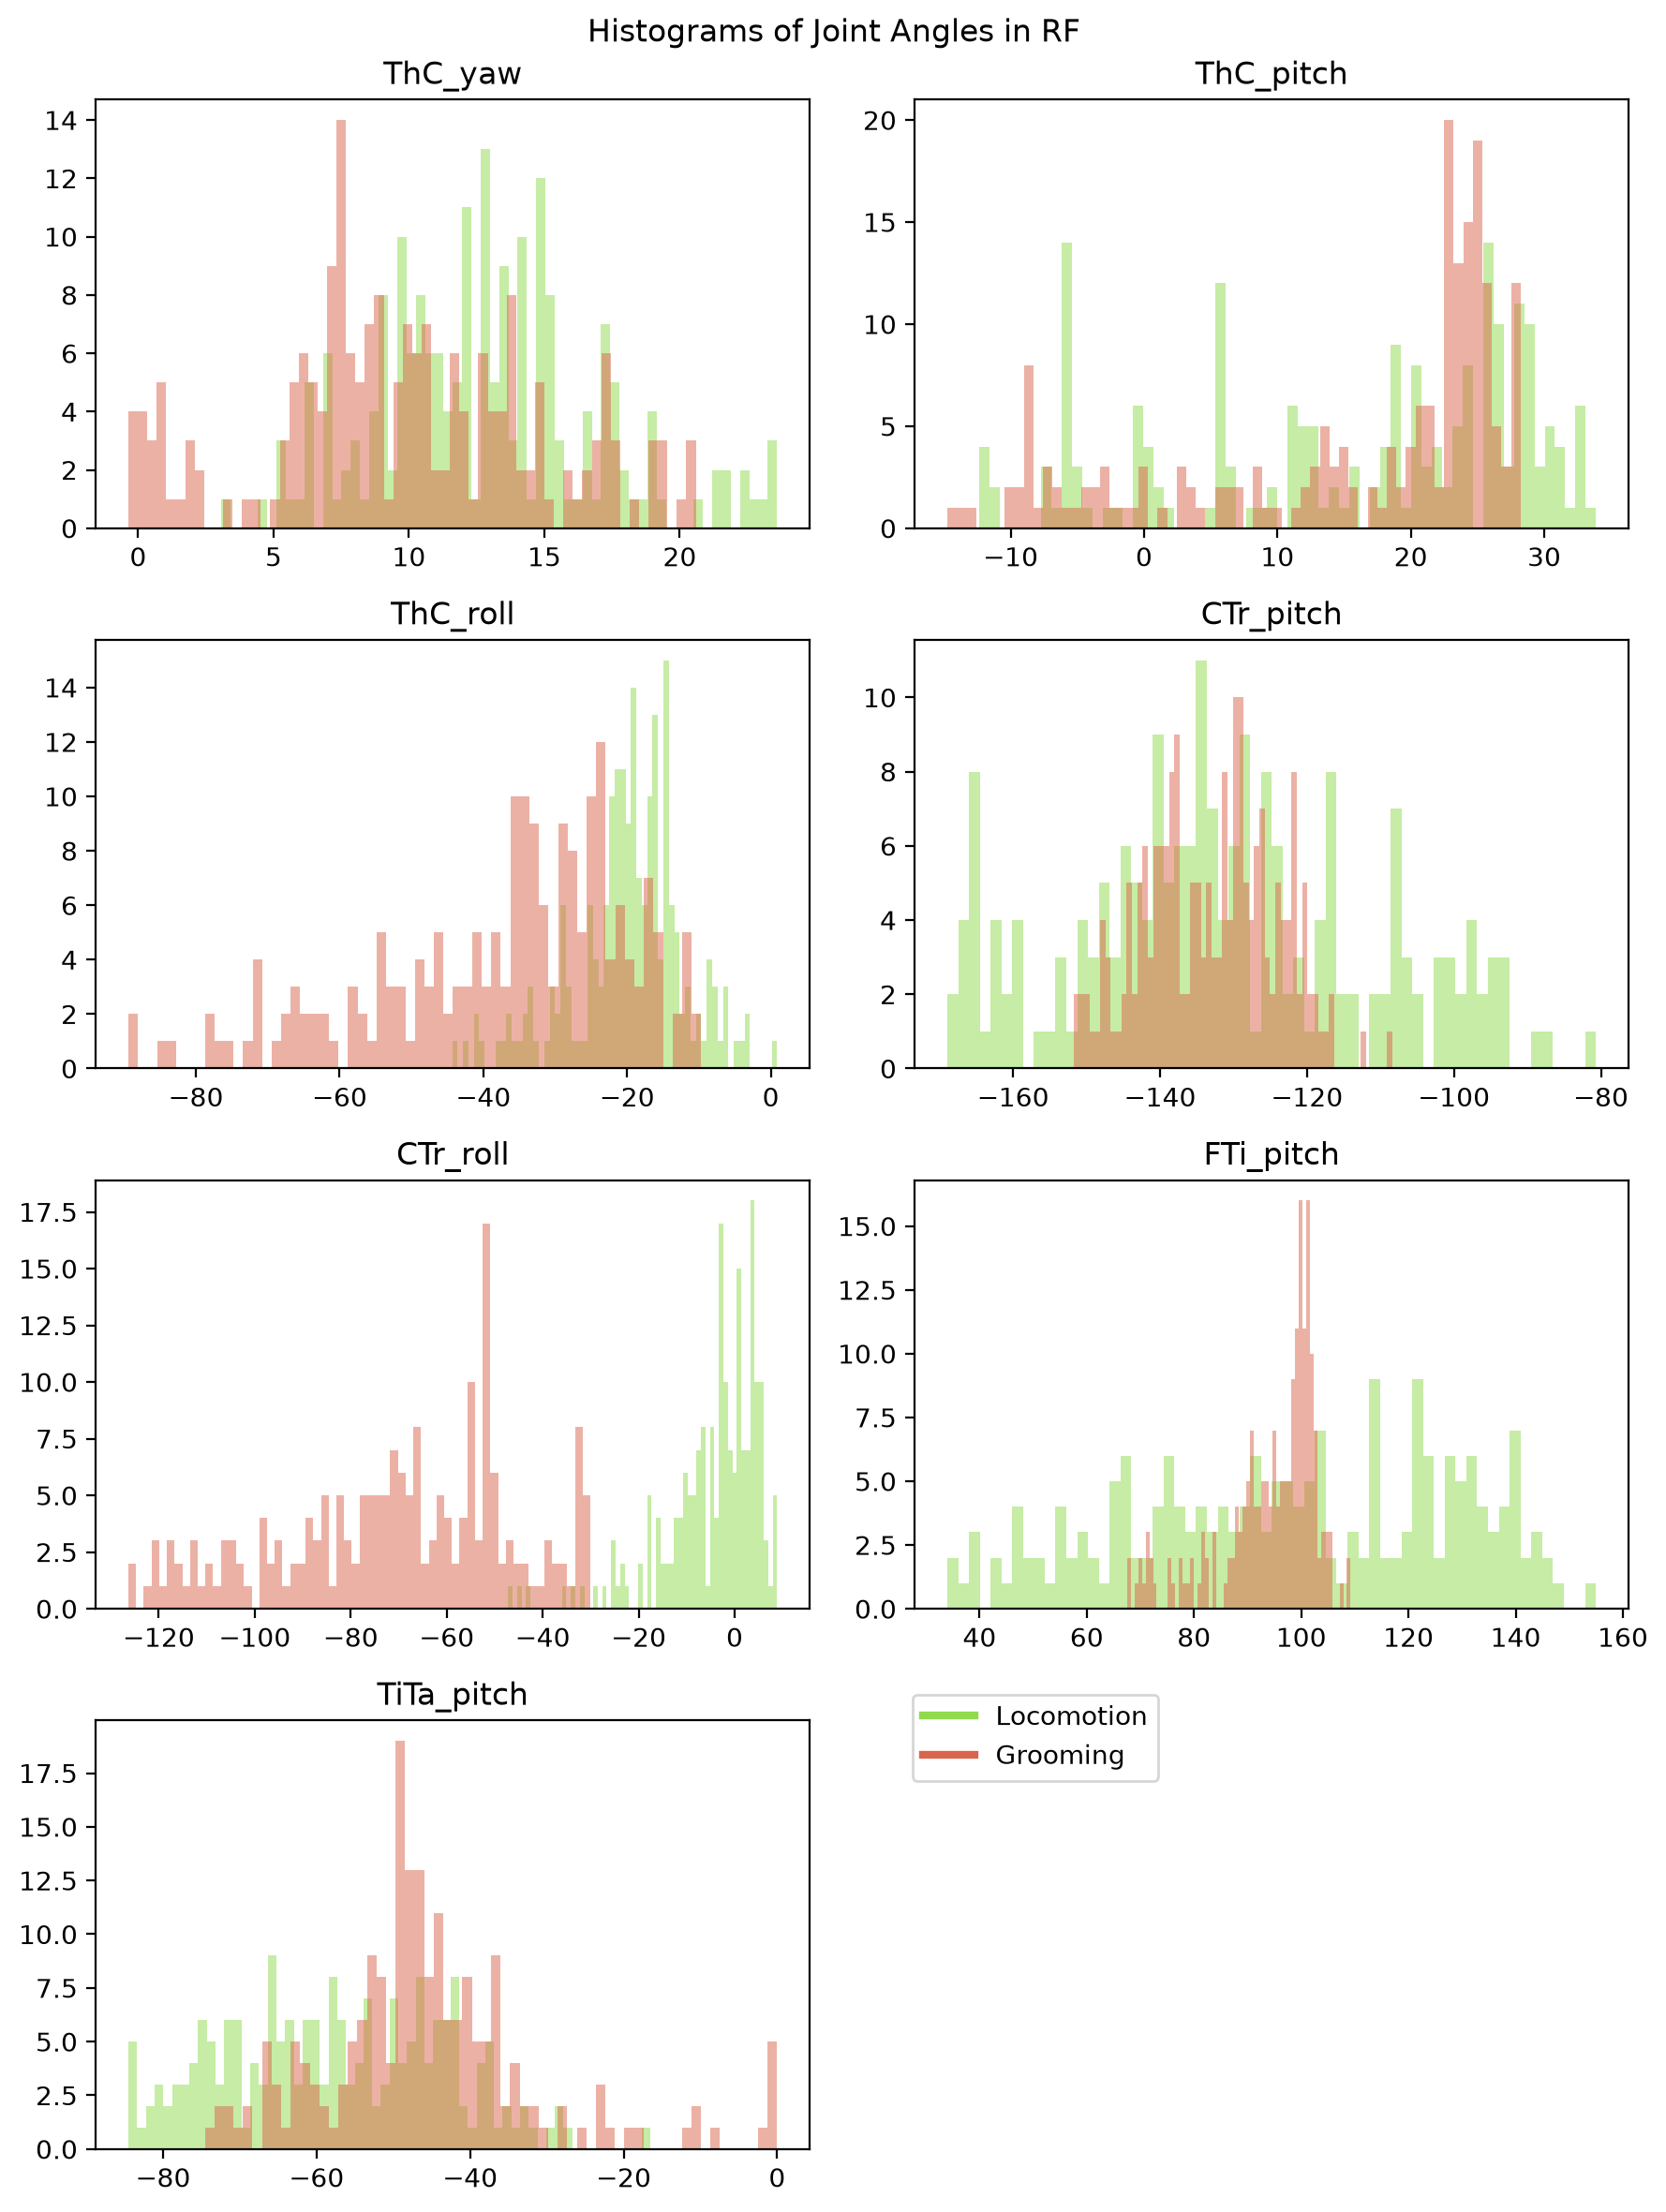

In [118]:
fig,axs= plt.subplots(4, 2, figsize=(9, 12), dpi=200)
axs=axs.flatten()
for i,angle in enumerate(leg_joint_angle_names):
    axs[i].hist(RF_locomotion_angles[angle], bins=60, alpha=0.5, color="#8fda4d")
    axs[i].hist(RF_grooming_angles[angle], bins=60, alpha=0.5, color="#da654d")
    axs[i].set_title(angle)

axs[-1].set_visible(False)

fig.legend(handles=[
    Line2D([0], [0], color="#8fda4d", markerfacecolor="#8fda4d", 
           markeredgecolor='black', markersize=6, linewidth=3, label='Locomotion'),
    Line2D([0], [0], color="#da654d", markerfacecolor="#da654d", 
           markeredgecolor='black', markersize=6, linewidth=3, label='Grooming')
],bbox_to_anchor=(0.7,0.24))
fig.suptitle("Histograms of Joint Angles in RF")
plt.tight_layout()
plt.show()

As we can see from histograms, ThC yaw and ThC pitch distrubutions are similar in locomotion and grooming. However in Ctr roll, it shows a significant difference in angle value distrubutions, just as we saw in min-max graphics. We can also say that the CTr pitch and FTi pitch angle values of grooming, especially the latter, have a smaller range than that of locomotion. Conversely for ThC roll, we can see that grooming has a larger range than locomotion. 